# J=2 state cleanup: R(2) F′=3 + F′=4

Migrated from `SPB_cleanup_J2_J3F4 copy.ipynb` to `centrex-tlf 0.2.5`.

- Uses the native Rust Lindblad backend; the Julia extension is no longer required.
- Retains the opposite-parity B-state partners explicitly.
- Preserves the final two-transition scheme: 80 mW on F′=3 and 24 mW on F′=4.
- Both lasers have independent 17.5 MHz EOM phase modulation with β=1.5.
- Frequencies and Rabi rates are angular frequencies in rad/s; E is V/cm and B is Gauss.


In [1]:
from importlib.metadata import version
import site
import sys

# Prefer the verified wheel over a source checkout with the same package name.
sys.path.insert(0, site.getsitepackages()[-1])

import matplotlib.pyplot as plt
import numpy as np

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions, utils

print("centrex-tlf", version("centrex-tlf"))
assert version("centrex-tlf") == "0.2.5"

from scripts.scan_hdf import load_scan_hdf, save_scan_hdf

from scripts.scan_progress import grid_scan_with_progress


centrex-tlf 0.2.5


In [2]:
plt.rcParams.update({
    "axes.titlesize": 24, "axes.labelsize": 20,
    "xtick.labelsize": 16, "ytick.labelsize": 16,
    "lines.linewidth": 2,
})

def gen_multipass_para(npass, loss, first_center, spacing):
    order = utils.multipass.multipass_prism_order(npass)
    xlocs = [first_center + i * spacing for i in range(npass)]
    ylocs = [0.0] * npass
    relative_power = [(1.0 - loss) ** (pass_number - 1) for pass_number in order]
    return xlocs, ylocs, relative_power


In [3]:
trans = [transitions.R2_F1_7o2_F3, transitions.R2_F1_7o2_F4]
polarizations = [
    [couplings.polarization_X, couplings.polarization_Z],
    [couplings.polarization_X, couplings.polarization_Z],
]

ground_mains = [
    1 * states.CoupledBasisState(
        J=2, F=3, F1=5/2, mF=2, I1=1/2, I2=1/2, Ω=0, P=1,
        electronic_state=states.ElectronicState.X,
    ),
    1 * states.CoupledBasisState(
        J=2, F=3, F1=5/2, mF=0, I1=1/2, I2=1/2, Ω=0, P=1,
        electronic_state=states.ElectronicState.X,
    ),
]
excited_mains = [
    1 * states.CoupledBasisState(
        J=3, F=3, F1=7/2, mF=3, I1=1/2, I2=1/2, Ω=1, P=-1,
        electronic_state=states.ElectronicState.B,
    ),
    1 * states.CoupledBasisState(
        J=3, F=4, F1=7/2, mF=1, I1=1/2, I2=1/2, Ω=1, P=-1,
        electronic_state=states.ElectronicState.B,
    ),
]
transition_selectors = couplings.generate_transition_selectors(
    trans, polarizations, ground_mains=ground_mains, excited_mains=excited_mains
)


In [4]:
# Experimental settings retained from the final notebook.
E_FIELD = np.array([0.0, 0.0, 250.0])       # V/cm
B_FIELD = np.array([0.0, 0.0, 1e-3])        # Gauss; resolves ±mF numerically
vz, vx = 184.0, 0.0                         # m/s
laser_frequency = 1.103e15                  # Hz, for Doppler conversion

power0_default = 80e-3                      # F′=3 laser, W
power1_default = 0.30 * power0_default       # F′=4 laser, W
detuning0_default = 18.5 * 2*np.pi*1e6      # rad/s
detuning1_default = -6.5 * 2*np.pi*1e6      # rad/s
eom0_default = 17.5 * 2*np.pi*1e6           # rad/s
eom1_default = 17.5 * 2*np.pi*1e6           # rad/s
beta0_default = beta1_default = 1.5
polarization_frequency_default = 0.5 * 2*np.pi*1e6

sigma_z_default, sigma_y_default = 0.75e-3, 6e-3
xlocs_default, ylocs_default, pass_power = gen_multipass_para(13, 0.10, 3.5e-3, 3.5e-3)
intensities_per_watt = tuple(
    np.asarray(pass_power) / (2*np.pi*sigma_z_default*sigma_y_default)
)
T_END = 0.05 / vz


In [ ]:
%%time
obe_system = lindblad.generate_OBE_system_transitions(
    trans,
    transition_selectors,
    verbose=True,
    qn_compact=True,
    E=E_FIELD,
    B=B_FIELD,
    retain_opposite_parity_levels=True,
    Jmax_X=5,
    Jmax_B=5,
)
print("levels:", len(obe_system.QN))
print("main couplings:", [abs(c.main_coupling) for c in obe_system.couplings])


INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
c:\Users\16612\anaconda3\envs\CeNTREX_state_cleanup_new\Lib\site-packages\centrex_tlf\states\find_states.py:635: UserWarning: Ambiguous eigenstate assignment for approximate states: 8 (assigned 8 at 0.391, runner-up 1 at 0.379), 10 (assigned 10 at 0.391, runner-up 3 at 0.379). The assigned eigenstate is not clearly preferred over the next candidate, so the labelling can change with a small change in field or with numerical noise. Treat this as a warning about the assignment as a whole, not only about the states listed: mis-assignments come in groups within a mixed manifold and a state can be assigned wrongly while its own margin looks acceptable. Track the states adiabatically instead: step the field up from ~0 in small increments and match each set of eigenvectors to the previous set.
  indices = find_exact_states_indices(
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 

levels: 40
main couplings: [np.float64(0.09395443068104227), np.float64(0.21655998777399918)]
CPU times: total: 21.5 s
Wall time: 16.9 s


In [11]:
%%time
params = lindblad.LindbladParameters()
t = params.time()

power0 = params.real("power0", power0_default)
power1 = params.real("power1", power1_default)
detuning0 = params.real("detuning0", detuning0_default)
detuning1 = params.real("detuning1", detuning1_default)
eom0 = params.real("eom0", eom0_default)
eom1 = params.real("eom1", eom1_default)
beta0 = params.real("beta0", beta0_default)
beta1 = params.real("beta1", beta1_default)
pol_frequency = params.real("pol_frequency", polarization_frequency_default)
y0 = params.real("y0", 0.0)
sigma_z = params.real("sigma_z", sigma_z_default)
sigma_y = params.real("sigma_y", sigma_y_default)
intensity_profile = params.real("intensities_per_watt", intensities_per_watt)
xlocs = params.real("xlocs", tuple(xlocs_default))
ylocs = params.real("ylocs", tuple(ylocs_default))

drives = []
for k, (power, beta, eom) in enumerate(((power0, beta0, eom0), (power1, beta1, eom1))):
    main_coupling = params.real(
        f"main_coupling{k}", float(abs(obe_system.couplings[k].main_coupling))
    )
    spatial = lindblad.multipass_2d_rabi(
        vz*t, y0, intensity_profile, xlocs, ylocs,
        sigma_z, sigma_y, main_coupling, 2.6675506e-30,
    )
    drives.append(power**0.5 * lindblad.phase_modulation(t, beta, eom) * spatial)

doppler_per_mps = float(utils.detuning.velocity_to_detuning(1.0, laser_frequency))
for selector, drive, detuning in zip(
    transition_selectors, drives, (detuning0, detuning1)
):
    params.bind(selector.Ω, drive, finalize=False)
    params.bind(selector.δ, detuning + vx*doppler_per_mps, finalize=False)

# Complementary X/Z switching: when laser 0 is X, laser 1 is Z, and vice versa.
z_gate = lindblad.square_wave(t, pol_frequency, 0.0)
px0, pz0 = transition_selectors[0].polarization_symbols
px1, pz1 = transition_selectors[1].polarization_symbols
params.bind(px0, 1.0-z_gate, finalize=False)
params.bind(pz0, z_gate, finalize=False)
params.bind(px1, z_gate, finalize=False)
params.bind(pz1, 1.0-z_gate, finalize=False)
params._finalize()

prepared = lindblad.prepare_lindblad_problem(
    obe_system, params, backend="rust", hamiltonian_representation="decomposed"
)


CPU times: total: 3.56 s
Wall time: 3.56 s


In [12]:
ground_idx = np.asarray(states.QuantumSelector(
    J=2, electronic=states.ElectronicState.X
).get_indices(obe_system.QN), dtype=int).ravel()
excited_idx = np.asarray(states.QuantumSelector(
    electronic=states.ElectronicState.B
).get_indices(obe_system.QN), dtype=int).ravel()

rho0 = np.zeros(obe_system.H_symbolic.shape, dtype=np.complex128)
rho0[ground_idx, ground_idx] = 1.0 / ground_idx.size
print("initial J=2 states:", ground_idx.size, "trace:", np.trace(rho0).real)


initial J=2 states: 20 trace: 1.0


In [13]:
saveat = np.append(np.arange(0.0, T_END, 1e-6), T_END)
solver_options = dict(
    solver="dopri5", execution_mode="expanded_sparse",
    dt=2e-9, reltol=1e-7, abstol=1e-9, maxiters=500_000,
)

results = lindblad.solve_lindblad(
    prepared, rho0, (0.0, T_END), saveat=saveat,
    output="populations", output_when="saveat", **solver_options,
)
populations = results.values


final trace = 0.9999999999999842
remaining J=2 population = 0.00017039928714372398
cleanup efficiency = 0.9998296007128563
photons per molecule = 1.5269429008552882


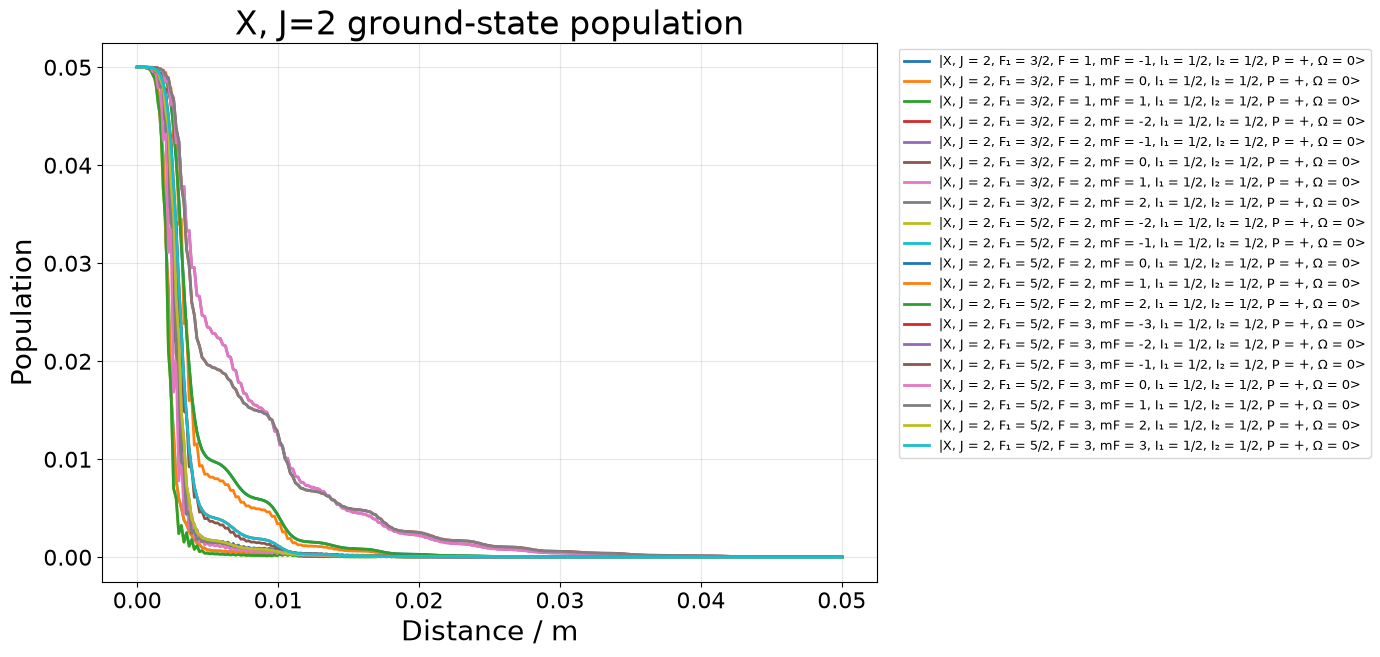

In [14]:
remaining_j2 = populations[-1, ground_idx].sum().real
photons = np.trapezoid(populations[:, excited_idx].sum(axis=1), x=results.t) * hamiltonian.Γ
print("final trace =", populations[-1].sum().real)
print("remaining J=2 population =", remaining_j2)
print("cleanup efficiency =", 1.0-remaining_j2)
print("photons per molecule =", photons.real)

fig, ax = plt.subplots(figsize=(10, 7))
for idx in ground_idx:
    ax.plot(results.t*vz, populations[:, idx], label=str(obe_system.QN[idx].largest))
ax.set(xlabel="Distance / m", ylabel="Population", title="X, J=2 ground-state population")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.show()


## Structured parameter scans

The final J=2 scheme has two independent transitions, `R(2), F′=3` and `R(2), F′=4`. The most direct scan varies both carrier detunings while keeping powers, both EOM settings, fields, multipass geometry and polarization switching fixed.

The saved quantity is final population remaining in the initial J=2 manifold; cleanup efficiency is `1 - remaining`. Frequencies are stored in MHz, although the solver receives rad/s.

In [ ]:
scan_solver_options = {
    **solver_options,
    "output": "populations",
    "output_when": "final",
    "parallel": True,
}

model_metadata = {
    "notebook": "SPB_cleanup_J2_J3F4_opposite_parity.ipynb",
    "centrex_tlf_version": version("centrex-tlf"),
    "transitions": [str(item) for item in trans],
    "retain_opposite_parity_levels": True,
    "number_of_levels": len(obe_system.QN),
    "initial_manifold": "X, J=2, uniform population",
    "initial_state_count": int(ground_idx.size),
}

fixed_conditions = {
    "electric_field_V_per_cm": E_FIELD.tolist(),
    "magnetic_field_G": B_FIELD.tolist(),
    "interaction_length_m": 0.05,
    "molecular_vz_m_per_s": vz,
    "molecular_vx_m_per_s": vx,
    "laser_frequency_Hz": laser_frequency,
    "Fprime3_power_mW": power0_default*1e3,
    "Fprime4_power_mW": power1_default*1e3,
    "Fprime3_eom_frequency_MHz": eom0_default/(2*np.pi*1e6),
    "Fprime4_eom_frequency_MHz": eom1_default/(2*np.pi*1e6),
    "Fprime3_modulation_depth_rad": beta0_default,
    "Fprime4_modulation_depth_rad": beta1_default,
    "polarization_switch_frequency_MHz": polarization_frequency_default/(2*np.pi*1e6),
    "polarization_scheme": "complementary X/Z switching",
    "sigma_z_mm": sigma_z_default*1e3,
    "sigma_y_mm": sigma_y_default*1e3,
    "multipass_count": len(xlocs_default),
    "multipass_relative_power": list(pass_power),
    "main_couplings": [float(abs(c.main_coupling)) for c in obe_system.couplings],
}


### F′=3 detuning × F′=4 detuning

Array shape is `[F′=3 detuning, F′=4 detuning]`. This order is retained in memory and in HDF5.

In [ ]:
# Coarse axes for validation; increase resolution for the final scan.
detuning0_MHz = np.linspace(-40.0, 40.0, 41)
detuning1_MHz = np.linspace(-40.0, 40.0, 41)

detuning_scan = grid_scan_with_progress(
    prepared, rho0, (0.0, T_END),
    scan={
        "detuning0": detuning0_MHz*2*np.pi*1e6,
        "detuning1": detuning1_MHz*2*np.pi*1e6,
    },
    **scan_solver_options,
    chunk_size=32,
    description="J=2 F′=3/F′=4 detuning",
)
detuning_populations = detuning_scan.values.reshape(
    len(detuning0_MHz), len(detuning1_MHz), len(obe_system.QN)
)
detuning_remaining = detuning_populations[..., ground_idx].sum(axis=-1).real
detuning_cleanup = 1.0-detuning_remaining
print("remaining-population shape [F′=3 detuning, F′=4 detuning] =", detuning_remaining.shape)


In [ ]:
scan_file = save_scan_hdf(
    "SPB_J2_cleanup_scans.h5",
    "Fprime3_Fprime4_detuning",
    detuning_remaining,
    axes={
        "Fprime3_detuning_MHz": (detuning0_MHz, "MHz"),
        "Fprime4_detuning_MHz": (detuning1_MHz, "MHz"),
    },
    quantity="final_population_remaining_in_X_J2",
    fixed_parameters=fixed_conditions,
    model=model_metadata,
    solver=scan_solver_options,
    notes="Two independent EOM-modulated lasers; opposite-parity B partners retained.",
    overwrite=False,  # Protect an existing long-running scan; change run_name for a new run.
)
print("saved:", scan_file)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(
    detuning1_MHz, detuning0_MHz, 100*detuning_cleanup, shading="auto"
)
fig.colorbar(mesh, ax=ax, label="Cleanup efficiency / %")
ax.set(xlabel="F′=4 carrier detuning / MHz", ylabel="F′=3 carrier detuning / MHz")
plt.show()


### HDF5 readback example

In [ ]:
saved_run = load_scan_hdf("SPB_J2_cleanup_scans.h5", "Fprime3_Fprime4_detuning")
print(saved_run["results"].shape)
print(saved_run["units"])
print(saved_run["fixed_parameters"])
